In [1]:
# Cell 1: Load SMOTE-balanced sequences and create time-based train/test split
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

X = np.load('../data/processed/X_sequences.npy')
y = np.load('../data/processed/y_labels.npy')

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"ATO=1   : {y.sum():,} ({y.mean()*100:.2f}%)")

# Time-based split — last 20% as test set
# Do NOT use random split: would leak future data into training
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"Train ATO=1: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test ATO=1 : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

X shape : (550566, 10, 32)
y shape : (550566,)
ATO=1   : 2,362 (0.43%)

Train size : 440,452
Test size  : 110,114
Train ATO=1: 1,725 (0.39%)
Test ATO=1 : 637 (0.58%)


In [2]:
# Cell 2: Define LSTM architecture
# 2-layer LSTM with dropout regularisation
# Binary classification output (ATO vs non-ATO)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

n_timesteps = X_train.shape[1]   # 10
n_features  = X_train.shape[2]   # 32

model = Sequential([
    # First LSTM layer — returns sequences for stacking
    LSTM(64, input_shape=(n_timesteps, n_features),
         return_sequences=True, name='lstm_1'),
    Dropout(0.3, name='dropout_1'),

    # Second LSTM layer — returns single vector
    LSTM(32, return_sequences=False, name='lstm_2'),
    Dropout(0.3, name='dropout_2'),

    # Batch normalisation for training stability
    BatchNormalization(name='batch_norm'),

    # Dense hidden layer
    Dense(16, activation='relu', name='dense_1'),
    Dropout(0.2, name='dropout_3'),

    # Output layer — sigmoid for binary classification
    Dense(1, activation='sigmoid', name='output')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,921 (148.13 KB)

 Trainable params: 37,857 (147.88 KB)

 Non-trainable params: 64 (256.00 B)

In [3]:
# Cell 3: Define class weights and training callbacks
# Class weights compensate for remaining imbalance after SMOTE
# EarlyStopping prevents overfitting, ModelCheckpoint saves best model

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from training labels
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print(f"Class weights: {class_weight_dict}")
print(f"  → ATO=0 weight : {class_weight_dict[0]:.4f}")
print(f"  → ATO=1 weight : {class_weight_dict[1]:.4f}")

# Callbacks
early_stop = EarlyStopping(
    monitor='val_recall',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='../outputs/models/lstm_best.keras',
    monitor='val_recall',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("\nCallbacks defined: EarlyStopping + ModelCheckpoint")
print("Monitoring: val_recall (primary target >90%)")

Class weights: {0: 0.5019659150223259, 1: 127.66724637681159}
  → ATO=0 weight : 0.5020
  → ATO=1 weight : 127.6672

Callbacks defined: EarlyStopping + ModelCheckpoint
Monitoring: val_recall (primary target >90%)


In [4]:
# Cell 4: Train the LSTM model
# Batch size 512 chosen for memory efficiency with large sequence array
# Validation split 20% of training data for hyperparameter monitoring

import os
os.makedirs('../outputs/models', exist_ok=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete.")
print(f"Best epoch stopped at: {len(history.history['loss'])} epochs")

Epoch 1/30
687/689 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7529 - auc: 0.8643 - loss: 0.4593 - recall: 0.8564
Epoch 1: val_recall improved from -inf to 0.91589, saving model to ../outputs/models/lstm_best.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7531 - auc: 0.8644 - loss: 0.4590 - recall: 0.8565 - val_accuracy: 0.7842 - val_auc: 0.9141 - val_loss: 0.3907 - val_recall: 0.9159
Epoch 2/30
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8266 - auc: 0.9104 - loss: 0.3586 - recall: 0.8980
Epoch 2: val_recall improved from 0.91589 to 0.92290, saving model to ../outputs/models/lstm_best.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8266 - auc: 0.9104 - loss: 0.3586 - recall: 0.8980 - val_accuracy: 0.8001 - val_auc: 0.9192 - val_loss: 0.3852 - val_recall: 0.9229
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8327 - auc: 0.9210 - loss: 0.3299 - recall: 0.9113
Epoch 3: val_recall did not improve from 0.92290
689/689 ━━━━━━

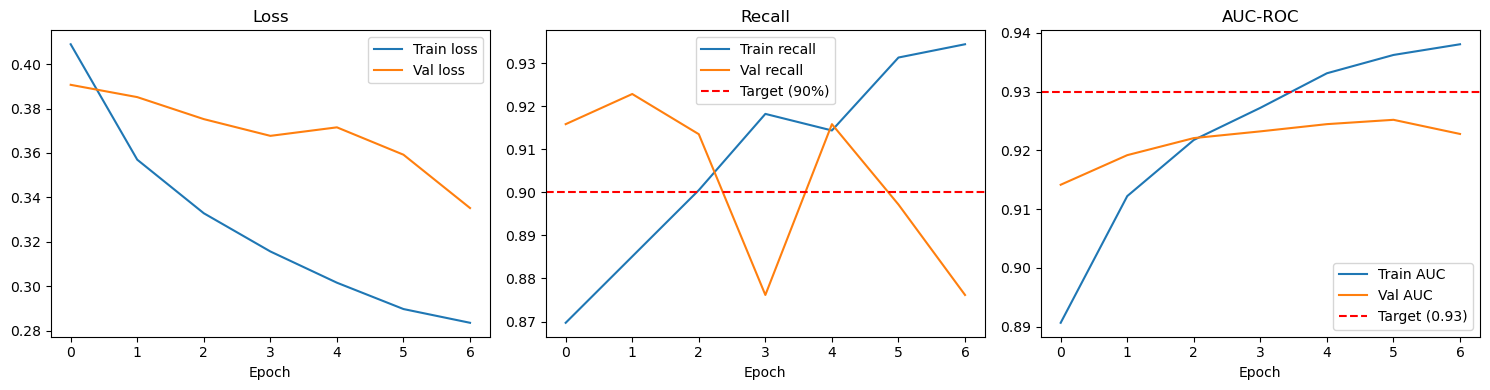

Saved: outputs/figures/training_history.png


In [5]:
# Cell 5: Visualise training history — loss, recall and AUC curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Recall
axes[1].plot(history.history['recall'], label='Train recall')
axes[1].plot(history.history['val_recall'], label='Val recall')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='Target (90%)')
axes[1].set_title('Recall')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# AUC
axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].axhline(y=0.93, color='red', linestyle='--', label='Target (0.93)')
axes[2].set_title('AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/training_history.png")

In [6]:
# Cell 6: Final evaluation on held-out test set
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

# Predict probabilities
y_pred_prob = model.predict(X_test, verbose=0).flatten()

# Convert to binary with 0.5 threshold
y_pred = (y_pred_prob >= 0.5).astype(int)

# Core metrics
print("=== TEST SET EVALUATION ===")
print(classification_report(y_test, y_pred,
                             target_names=['Non-ATO', 'ATO']))

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC : {auc_score:.4f}  (target >0.93)")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:,}  FP: {cm[0,1]:,}")
print(f"  FN: {cm[1,0]:,}  TP: {cm[1,1]:,}")
print(f"\nFalse Negative Rate : {cm[1,0]/(cm[1,0]+cm[1,1])*100:.2f}%")
print(f"False Positive Rate : {cm[0,1]/(cm[0,0]+cm[0,1])*100:.2f}%")

=== TEST SET EVALUATION ===
              precision    recall  f1-score   support

     Non-ATO       1.00      0.86      0.93    109477
         ATO       0.04      0.94      0.07       637

    accuracy                           0.87    110114
   macro avg       0.52      0.90      0.50    110114
weighted avg       0.99      0.87      0.92    110114

AUC-ROC : 0.9441  (target >0.93)

Confusion Matrix:
  TN: 94,661  FP: 14,816
  FN: 41  TP: 596

False Negative Rate : 6.44%
False Positive Rate : 13.53%


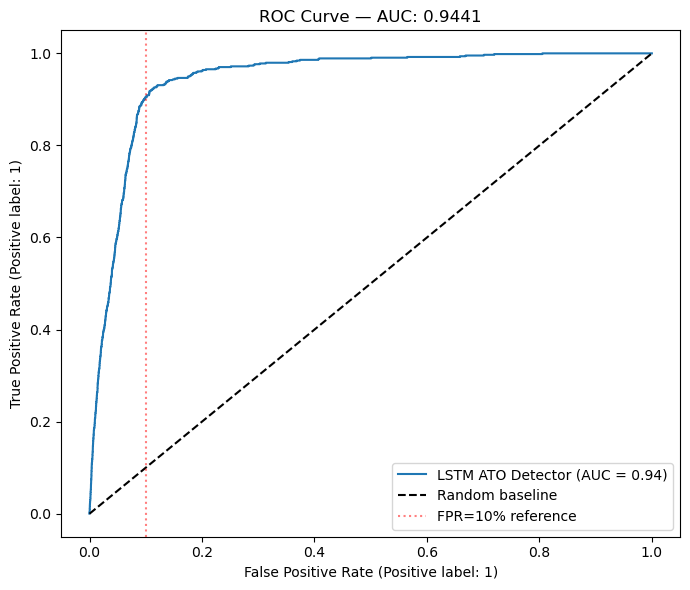

Saved: outputs/figures/roc_curve.png
Saved: outputs/models/lstm_final.keras

Next step -> 05_evaluation.ipynb


In [7]:
# Cell 7: Plot ROC curve and save final model
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=ax,
                                  name='LSTM ATO Detector')
ax.plot([0,1], [0,1], 'k--', label='Random baseline')
ax.axvline(x=0.1, color='red', linestyle=':', alpha=0.5, label='FPR=10% reference')
ax.set_title(f'ROC Curve — AUC: {auc_score:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/roc_curve.png")

# Save final model
model.save('../outputs/models/lstm_final.keras')
print("Saved: outputs/models/lstm_final.keras")
print(f"\nNext step -> 05_evaluation.ipynb")